In [6]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic

import cv2
from PIL import Image


In [35]:
def show_img(img, title=None, cmap=None, bgr=False, title_size=8, figsize=None):
    if 'torch' in sys.modules and torch.is_tensor(img):
        if len(img.shape)==2: img= img.unsqueeze(dim=0)
        img = img.permute(1, 2, 0)
    fig = plt.figure(figsize=figsize)#, dpi=72)
    ax = fig.subplots(1, 1)
    ax.axis('off')
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title: ax.set_title(title, **STYLE_PLOT_TITLE)
    if cmap is None:
        cmap = 'gray' if len(img.shape)==2 else None
    if bgr and len(img.shape)==3 and img.shape[2]==3:
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img, cmap=cmap)
    plt.show()
    return ax

#imgs: [array(H,W)[:int32]]
def show_imgs(imgs, titles=None, cmap=None, ncols=None, nrows=None, bgr=False, title_size=4, figsize=None, pad=0):
    if ncols==None:
        if nrows==None: ncols=1
        else: ncols=int(len(imgs)/nrows) + (len(imgs) % nrows > 0)
    if isinstance(imgs, list):
        imgs = np.array(imgs)
    if nrows==None:
        nrows=int(imgs.shape[0]/ncols) + (imgs.shape[0] % ncols > 0)
    fig = plt.figure(figsize=figsize) #, dpi=72)
    axs = fig.subplots(nrows, ncols)
    axs = axs.flatten()
    plt.subplots_adjust(top=1-pad, bottom=0+pad, left=0+pad, right=1-pad, wspace=pad, hspace=pad) 
    #print('!!',nrows, ncols, axs)
    for ax in axs:
        ax.axis('off')
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.tick_params(left=False)
    for i in range(imgs.shape[0]):
        img = imgs[i] 
        if cmap is None:
            cmap_ = 'gray' if len(img.shape)==2 else None
        else:
            cmap_ = cmap[i] if isinstance(cmap, list) else cmap
        if bgr and len(img.shape)==3 and img.shape[2]==3:
            img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap=cmap_)
        STYLE_PLOT_TITLE= {'fontsize': title_size }
        if titles and i<len(titles):
            axs[i].set_title(str(titles[i]), **STYLE_PLOT_TITLE)
    plt.show()
    return axs

    
def cv_bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [20]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data        # shape (70000, 784)
y = mnist.target     # labels as strings



(70000, 784) (70000,)
(70000, 28, 28) (70000,)


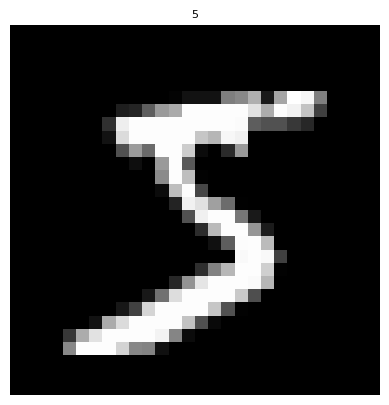

<Axes: title={'center': '5'}>

In [ ]:
print(X.shape, y.shape)
y_ = y.astype(int) # Convert labels to int
X_ = X.reshape(-1, 28, 28)
print(X_.shape, y.shape)
show_img(X_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)



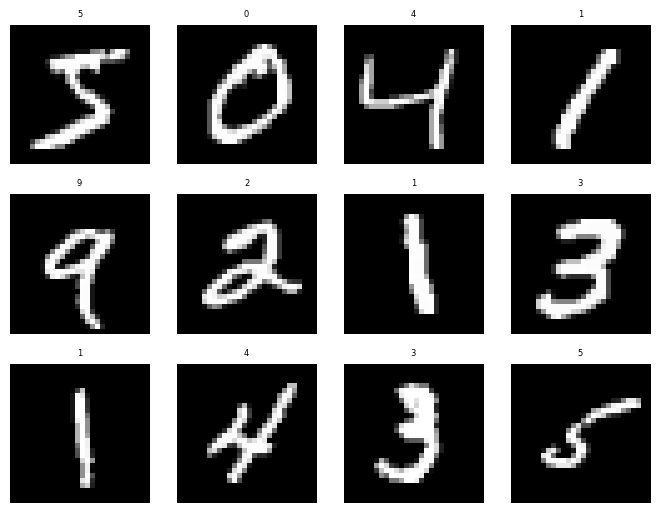

array([<Axes: title={'center': '5'}>, <Axes: title={'center': '0'}>,
       <Axes: title={'center': '4'}>, <Axes: title={'center': '1'}>,
       <Axes: title={'center': '9'}>, <Axes: title={'center': '2'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '3'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '4'}>,
       <Axes: title={'center': '3'}>, <Axes: title={'center': '5'}>],
      dtype=object)

In [ ]:
show_imgs(X_[:12], titles=y[:12].tolist(), ncols=4, nrows=None, title_size=6, figsize=None, pad=0)


(70000, 28, 28)
(3, 3, 9, 9)
(3, 3, 9, 9) (9, 9, 9) (9, 81)


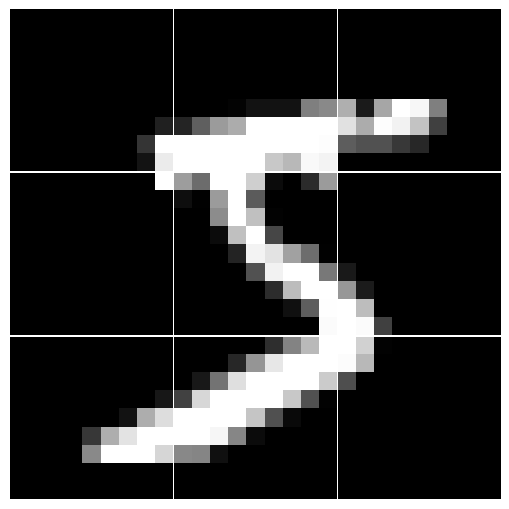

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [43]:
from numpy.lib.stride_tricks import sliding_window_view

def tiles(a, K, S):
    tiles = sliding_window_view(a, (K, K))
    return tiles[::S, ::S]

print(X_.shape)

Xs=tiles(X_[0], K=9, S=9)
print(Xs.shape)

Xs_ = Xs.reshape(-1, *Xs.shape[2:])
Xs__ = Xs_.reshape(Xs_.shape[0], -1)
print(Xs.shape, Xs_.shape, Xs__.shape)
show_imgs(Xs_, titles=None, ncols=Xs.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)





In [ ]:
 for i in range(0, Xs__.shape[0]):
    Xs_
    self.Zp = np.outer(zy, zs)
    self.Zn = np.outer(zy, 1-zs)

In [ ]:
A=Xs__
A_ = A[:, :, None] * A[:, None, :]
print(A.shape, out.shape)

show_imgs(A_, titles=None, ncols=A_.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)


(9, 81) (9, 81, 81)


(784,) int64
(784, 784)


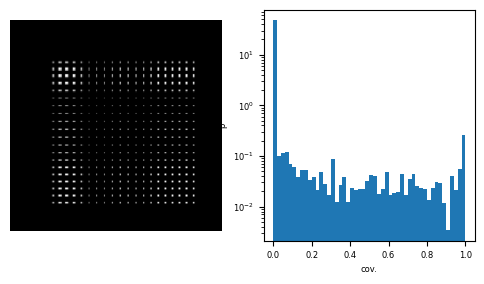

In [119]:
Xf = X.astype(float)/255
print(X[0].shape, X.dtype)
C = np.outer(Xf[0], Xf[0])
print(C.shape)
#for T in np.linspace(0, .1, num=22):
#    print(T, C.shape[0]*C.shape[0], np.sum(C>=T))

def show_cov(C, title=None, title_size=6, figsize=(2*3,1*3)):
    fig = plt.figure(figsize=figsize) #, dpi=72)
    axs = fig.subplots(1, 2)
    for ax in [axs[0]]:
        ax.axis('off')
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.tick_params(left=False)
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title:
        ax.set_title(title, **STYLE_PLOT_TITLE)
    axs[0].imshow(C, cmap='gray')
    C_ = C.flatten()
    ax = axs[1]
    ax.hist(C_, bins=50, density=True)
    ax.set_xlabel("cov.", fontsize=6)
    ax.set_ylabel("p", fontsize=6)
    ax.set_yscale("log")
    ax.tick_params(axis='both', labelsize=6)
    plt.show()

show_cov(C)


(784,) (784, 784)
(16, 784)
(16, 28, 28)


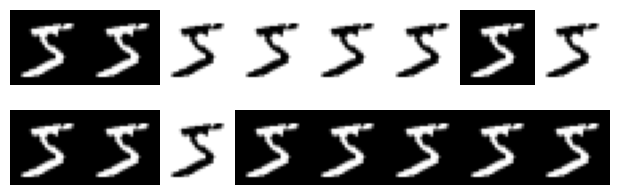

In [130]:
m = np.zeros(C.shape[0]) + .5
print(m.shape, C.shape)
x = np.random.multivariate_normal(m, C*20, 16)
print(x.shape)
x_ = x.reshape(-1, 28, 28)
print(x_.shape)
x__ = x_*255
#show_img(x__[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
_=show_imgs(x__, titles=y[:0].tolist(), ncols=8, nrows=None, title_size=6, figsize=(6*1, 2*1), pad=0)
#print(x_[0][14])
#print(x_[1][14])
#print(x__[0][14])
#print(x__[1][14])


(70000, 784) (70000, 28, 28) (70000,)


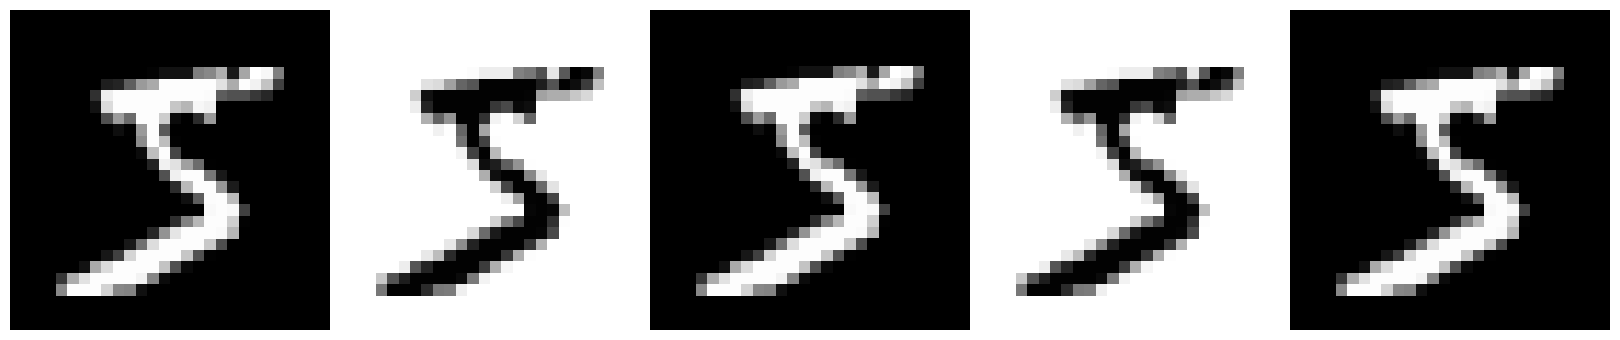

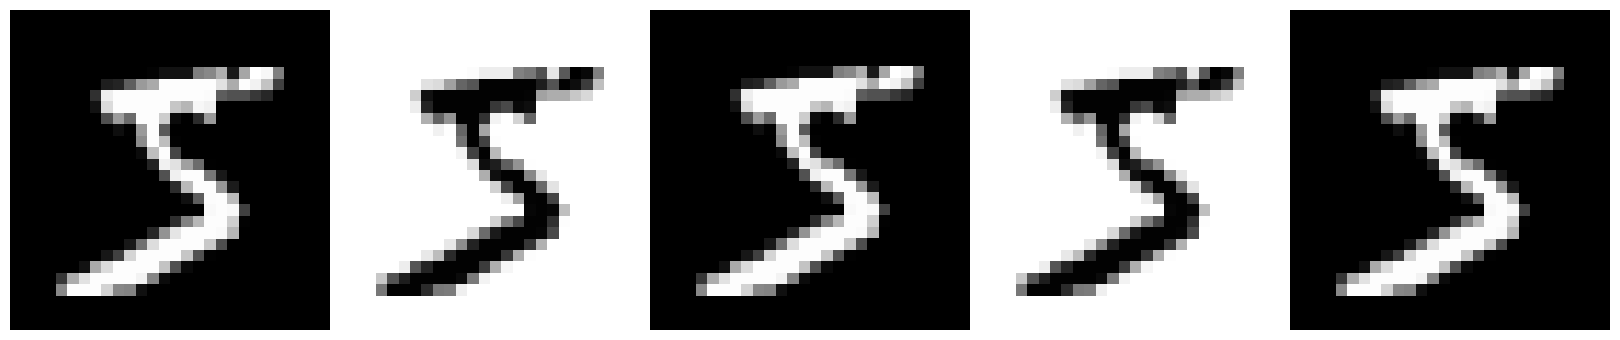

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.31764706 0.94117647 0.99215686 0.99215686 0.46666667
 0.09803922 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[  0   0   0   0   0   0   0   0   0   0   0   0   0  81 240 253 253 119
  25   0   0   0   0   0   0   0   0   0]
0 [ 0.49999936  0.49999983  0.49999901  0.5000003   0.49999922  0.49999935
  0.50000068  0.49999987  0.50000017  0.49999992  0.50000049  0.50000035
  0.49999947 -1.052124   -4.09888617 -4.34799292 -4.34799267 -1.78028127
  0.02094962  0.49999972  0.49999961  0.50000081  0.50000098  0.49999977
  0.50000028  0.49999983  0.50000033  0.49999979]
0 [  127.49983682   127.49995619   127.49974806   127.50007751
   127.49980091   127.49983343   127.50017235   127.49996658
   127.5000437    127.49997928   127.50012597   127.50009029
   127.49986583  -268.29162106 -1045.21597342 -1108.73819396
 -110

In [129]:
Xf_ = Xf.reshape(-1, 28, 28)
print(Xf.shape, Xf_.shape, y.shape)
_=show_imgs([Xf_[0], x_[0], x_[1], x_[2],x_[3]], ncols=5, figsize=(4*4, 1*4))
_=show_imgs([X_[0], x__[0], x__[1], x__[2],x__[3]], ncols=5, figsize=(4*4, 1*4))
print(Xf_[0,14])
print(X_[0,14])
for i in range(0, 2):
    print(i, x_[i,14])
    print(i, x__[i,14])



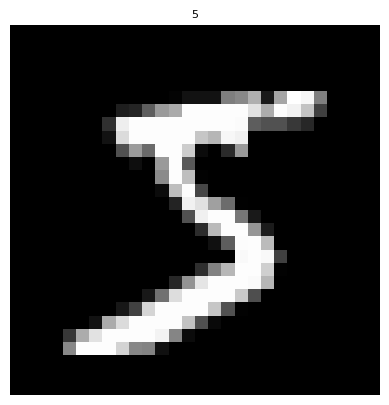

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.31764706 0.94117647 0.99215686 0.99215686 0.46666667
 0.09803922 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


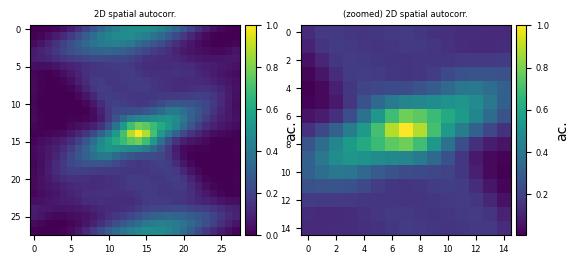

(28, 28)
(20,)
(28,)
[ 0.62068435  0.78954248  1.41571703  2.26314494  3.54723568  6.40573626
  9.73391772 13.74465206 20.17777778 28.84545944 38.59698577 49.5559554
 64.51972318 80.94482122 91.34955786 80.94482122 64.51972318 49.5559554
 38.59698577 28.84545944 20.17777778 13.74465206  9.73391772  6.40573626
  3.54723568  2.26314494  1.41571703  0.78954248]
[1.         0.77813617 0.51393669 0.3559112  0.27732527 0.22789879
 0.1886148  0.16005668 0.13980236 0.12518339 0.11838544 0.12965896
 0.14231173 0.1633268  0.1495034  0.0929083  0.06888362 0.04666722
 0.01479346 0.00290013]
[0.11651729 0.09573387 0.06687734 0.04852587 0.03957335 0.03465122
 0.03009878 0.02715575 0.02518912 0.02390901 0.02357183 0.02401301
 0.02431064 0.02408318 0.02192003 0.01734264 0.0137514  0.01039878
 0.00804056 0.00497895 0.00491945 0.00318956 0.00307188 0.00176945
 0.00187991 0.00045954 0.0002656  0.        ]


In [165]:
def autocorr2d_fft(f):
    F = np.fft.fft2(f)
    S = np.abs(F)**2
    C = np.fft.ifft2(S).real
    C = np.fft.fftshift(C)  # center at zero displacement
    return C

def autocorr_radial(C):
    ny, nx = C.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny // 2, nx // 2
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)

    tbin = np.bincount(r.ravel(), C.ravel())
    nr = np.bincount(r.ravel())

    return tbin / nr

def autocorr_radial2(f, max_r):
    h, w = f.shape
    C = np.zeros(max_r)
    N = np.zeros(max_r)

    for y in range(h):
        for x in range(w):
            for dy in range(-max_r, max_r+1):
                for dx in range(-max_r, max_r+1):
                    r = int(np.sqrt(dx*dx + dy*dy))
                    if r < max_r:
                        y2, x2 = y+dy, x+dx
                        if 0 <= y2 < h and 0 <= x2 < w:
                            C[r] += f[y, x] * f[y2, x2]
                            N[r] += 1
    return C / N

from mpl_toolkits.axes_grid1 import make_axes_locatable
def show_autocorr2d(ac2d, figsize=None):
    fig = plt.figure(figsize=figsize) #, dpi=72)
    axs = fig.subplots(1, 2)
    im0 = axs[0].imshow(ac2d)
    div0 = make_axes_locatable(axs[0])
    cax0 = div0.append_axes('right', size='5%', pad=0.05)
    cbar0 = fig.colorbar(im0, cax=cax0, orientation='vertical', label="ac.")
    cbar0.ax.tick_params(labelsize=6)
    axs[0].set_title("2D spatial autocorr.", fontsize=6)
    axs[0].tick_params(axis='both', labelsize=6)
    ny, nx = ac2d.shape
    cy, cx = ny // 2, nx // 2
    R = min(ny, nx)//4  # radius in pixels
    ac2d_ = ac2d[cy-R:cy+R+1, cx-R:cx+R+1]
    im1 = axs[1].imshow(ac2d_)
    div1 = make_axes_locatable(axs[1])
    cax1 = div1.append_axes('right', size='5%', pad=0.05)
    cbar1 = fig.colorbar(im1, cax=cax1, orientation='vertical', label="ac.")
    cbar1.ax.tick_params(labelsize=6)
    axs[1].set_title("(zoomed) 2D spatial autocorr.", fontsize=6)
    axs[1].tick_params(axis='both', labelsize=6)
    plt.show()
    

show_img(Xf_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
print(Xf_[0,14])
ac2d = autocorr2d_fft(Xf_[0])
ac2d_ = ac2d/ac2d[Xf_[0].shape[0]//2, Xf_[0].shape[1]//2]
show_autocorr2d(ac2d_)
acr = autocorr_radial(ac2d)
acr /= acr[0]
acr2 = autocorr_radial2(Xf_[0], Xf_.shape[1])
print(ac2d.shape)
print(acr.shape)
print(acr2.shape)
print(ac2d[14])
print(acr)
print(acr2)


In [133]:
grid = np.indices((2, 3))
grid

array([[[0, 0, 0],
        [1, 1, 1]],

       [[0, 1, 2],
        [0, 1, 2]]])